In [1]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.8 MB/s eta 0:00:00


In [2]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 54.1 MB/s eta 0:00:00


In [3]:
# 필요 라이브러리 임포트
import os
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

import time
from tqdm import tqdm
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,             # AUROC
    average_precision_score,   # AUPR
    recall_score,              # Recall
    f1_score,                  # F1
    fbeta_score,               # F-beta
    precision_score,           # Precision (F1 계산 참고용)
    confusion_matrix           # TP/FP/TN/FN 확인용
)

In [4]:
# ================================
# 0) 재현성(reproducibility) 설정
# ================================
def set_seed(seed: int = 11) -> None:
    """실험 결과를 최대한 재현 가능하게 만들기 위한 시드 고정 함수"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # GPU 사용 시 GPU용 난수 시드도 함께 고정
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

In [5]:
# ===================================================
# 하이퍼파라미터 (Supplementary Table S3. MOLI_Complete_Pan_Drug)
# ===================================================

# Encoder
HIDDEN_DIM_EXPR = 32
HIDDEN_DIM_MUT  = 16
HIDDEN_DIM_CNA  = 256

# Drug Embedding
DRUG_TO_IDX = {
    'Cetuximab' : 0,
    'Afatinib'  : 1,
    'Erlotinib' : 2,
    'Gefitinib' : 3,
    'Lapatinib' : 4
}
IDX_TO_DRUG  = {v: k for k, v in DRUG_TO_IDX.items()}
NUM_DRUGS    = len(DRUG_TO_IDX)   # 5
DRUG_EMB_DIM = 8                  # 약물 임베딩 차원

# Classifier
Z_IN            = HIDDEN_DIM_EXPR + HIDDEN_DIM_MUT + HIDDEN_DIM_CNA  # 304
Z_TOTAL = Z_IN + DRUG_EMB_DIM     # 304 + 8 = 312

# Learning Rate
LR_EXPR = 0.001
LR_MUT  = 0.0001
LR_CNA  = 5e-5
LR_CLS  = 0.005

# Dropout
DROPOUT_EXPR = 0.5
DROPOUT_MUT  = 0.8
DROPOUT_CNA  = 0.5
DROPOUT_CLS  = 0.3

# 학습 설정
WEIGHT_DECAY = 0.0001
BATCH_SIZE   = 16
GAMMA        = 0.5
MARGIN       = 1.5
EPOCHS       = 20
FOLDS        = 5   # Cross Validation 구현 시 사용


print("📋 하이퍼파라미터 (Table S3 MOLI_Complete_Pan_Drug 기준)")
print(f"  Encoder hidden : expr={HIDDEN_DIM_EXPR} / mut={HIDDEN_DIM_MUT} / cna={HIDDEN_DIM_CNA}")
print(f"  Z_IN           : {Z_IN}  (encoder concat)")
print(f"  Drug Embedding : {NUM_DRUGS}약물 × {DRUG_EMB_DIM}차원")
print(f"  Z_TOTAL        : {Z_TOTAL}  (Z_IN + drug_emb)")
print(f"  LR             : expr={LR_EXPR} / mut={LR_MUT} / cna={LR_CNA} / cls={LR_CLS}")
print(f"  Dropout        : expr={DROPOUT_EXPR} / mut={DROPOUT_MUT} / cna={DROPOUT_CNA} / cls={DROPOUT_CLS}")
print(f"  weight_decay   : {WEIGHT_DECAY} (classifier only)")
print(f"  batch={BATCH_SIZE} / gamma={GAMMA} / margin={MARGIN} / epochs={EPOCHS}")

📋 하이퍼파라미터 (Table S3 MOLI_Complete_Pan_Drug 기준)
  Encoder hidden : expr=32 / mut=16 / cna=256
  Z_IN           : 304  (encoder concat)
  Drug Embedding : 5약물 × 8차원
  Z_TOTAL        : 312  (Z_IN + drug_emb)
  LR             : expr=0.001 / mut=0.0001 / cna=5e-05 / cls=0.005
  Dropout        : expr=0.5 / mut=0.8 / cna=0.5 / cls=0.3
  weight_decay   : 0.0001 (classifier only)
  batch=16 / gamma=0.5 / margin=1.5 / epochs=20


In [6]:
# ===================================================
# 1) 데이터 로드
# ===================================================

BASE_DIR = "/content/drive/MyDrive/AI Health care 실습파일/MOLI"
save_dir = os.path.join(BASE_DIR, "preprocessed_EGFRi")

# Train
X_train_expr = np.load(f"{save_dir}/X_train_expr.npy")
X_train_mut  = np.load(f"{save_dir}/X_train_mut.npy")
X_train_cna  = np.load(f"{save_dir}/X_train_cna.npy")
drug_id_train = np.load(f"{save_dir}/drug_id_train.npy")
y_train      = np.load(f"{save_dir}/y_train.npy")

# Val (PDX)
X_val_expr   = np.load(f"{save_dir}/X_val_expr.npy")
X_val_mut    = np.load(f"{save_dir}/X_val_mut.npy")
X_val_cna    = np.load(f"{save_dir}/X_val_cna.npy")
drug_id_val  = np.load(f"{save_dir}/drug_id_val.npy")
y_val        = np.load(f"{save_dir}/y_val.npy")

# Val (TCGA)
X_tcga_expr  = np.load(f"{save_dir}/X_tcga_expr.npy")
X_tcga_mut   = np.load(f"{save_dir}/X_tcga_mut.npy")
X_tcga_cna   = np.load(f"{save_dir}/X_tcga_cna.npy")
drug_id_tcga = np.load(f"{save_dir}/drug_id_tcga.npy")
y_tcga       = np.load(f"{save_dir}/y_tcga.npy")

# 입력 차원
INPUT_DIM_EXPR = X_train_expr.shape[1]  # 18232
INPUT_DIM_MUT  = X_train_mut.shape[1]   # 14447
INPUT_DIM_CNA  = X_train_cna.shape[1]   # 20503

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("✅ 데이터 로드 완료")
print(f"  Train: {X_train_expr.shape[0]}샘플 | R:{int((y_train==0).sum())} S:{int((y_train==1).sum())}")
print(f"  PDX  : {X_val_expr.shape[0]}샘플   | R:{int((y_val==0).sum())} S:{int((y_val==1).sum())}")
print(f"  TCGA : {X_tcga_expr.shape[0]}샘플   | R:{int((y_tcga==0).sum())} S:{int((y_tcga==1).sum())}")
print(f"\n📐 입력 차원:")
print(f"  Expression : {INPUT_DIM_EXPR:,}")
print(f"  Mutation   : {INPUT_DIM_MUT:,}")
print(f"  CNA        : {INPUT_DIM_CNA:,}")
print(f"\n💊 Drug ID 확인:")
print(f"  Train drug_id : {drug_id_train.shape} dtype={drug_id_train.dtype}")
print(f"  Val   drug_id : {drug_id_val.shape}   dtype={drug_id_val.dtype}")
print(f"  TCGA  drug_id : {drug_id_tcga.shape}  dtype={drug_id_tcga.dtype}")
print(f"  매핑: {IDX_TO_DRUG}")
print(f"\n🖥️  장치: {device}")

✅ 데이터 로드 완료
  Train: 3258샘플 | R:2747 S:511
  PDX  : 81샘플   | R:73 S:8
  TCGA : 15샘플   | R:8 S:7

📐 입력 차원:
  Expression : 18,232
  Mutation   : 14,447
  CNA        : 20,503

💊 Drug ID 확인:
  Train drug_id : (3258,) dtype=int64
  Val   drug_id : (81,)   dtype=int64
  TCGA  drug_id : (15,)  dtype=int64
  매핑: {0: 'Cetuximab', 1: 'Afatinib', 2: 'Erlotinib', 3: 'Gefitinib', 4: 'Lapatinib'}

🖥️  장치: cuda


In [7]:
# 오믹스 데이터셋 클래스 생성
class OmicsDataset(Dataset):
    """
    3가지 Omics 데이터를 하나의 Dataset으로 묶는 클래스
    논문 Figure 1 입력 구조 구현
    """
    def __init__(self, expr, mut, cna, drug_ids, labels):
        self.expr     = torch.FloatTensor(expr)
        self.mut      = torch.FloatTensor(mut)
        self.cna      = torch.FloatTensor(cna)
        self.drug_ids = torch.LongTensor(drug_ids)
        self.labels   = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.expr[idx],
            self.mut[idx],
            self.cna[idx],
            self.drug_ids[idx],
            self.labels[idx]
        )

In [8]:
# ===================================================
# 2) Dataset + DataLoader
# ===================================================

# 2-1) Dataset 생성
train_dataset = OmicsDataset(X_train_expr, X_train_mut, X_train_cna, drug_id_train, y_train)
val_dataset   = OmicsDataset(X_val_expr,   X_val_mut,   X_val_cna,   drug_id_val,   y_val)
tcga_dataset  = OmicsDataset(X_tcga_expr,  X_tcga_mut,  X_tcga_cna,  drug_id_tcga,  y_tcga)

# 2-2) Oversampling (Train만 적용)
class_counts   = np.bincount(y_train.astype(int))
class_weights  = 1.0 / class_counts
sample_weights = torch.FloatTensor([class_weights[int(y)] for y in y_train])
sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

print(f"클래스 분포 - R:{class_counts[0]} / S:{class_counts[1]}")
print(f"클래스 가중치 - R:{class_weights[0]:.4f} / S:{class_weights[1]:.4f}")

# 2-3) DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    sampler    = sampler,
    drop_last  = True    # BatchNorm1d: 배치 크기 1 방지
)
val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False)
tcga_loader = DataLoader(tcga_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2-4) 확인
expr_b, mut_b, cna_b, drug_b, label_b = next(iter(train_loader))
print(f"\nTrain: {len(train_dataset)}샘플 / {len(train_loader)}배치")
print(f"PDX  : {len(val_dataset)}샘플")
print(f"TCGA : {len(tcga_dataset)}샘플")
print(f"\n배치 shape:")
print(f"  expr    : {tuple(expr_b.shape)}")
print(f"  mut     : {tuple(mut_b.shape)}")
print(f"  cna     : {tuple(cna_b.shape)}")
print(f"  drug_id : {tuple(drug_b.shape)}  dtype={drug_b.dtype}  ← LongTensor")
print(f"  label   : {tuple(label_b.shape)}")

# 2-5) Oversampling 검증
labels_sampled = []
for *_, lbl in train_loader:
    labels_sampled.extend(lbl.numpy())
labels_sampled = np.array(labels_sampled)
print(f"\n✅ Oversampling 후 분포:")
print(f"  R(0): {int((labels_sampled==0).sum())} ({(labels_sampled==0).mean()*100:.1f}%)")
print(f"  S(1): {int((labels_sampled==1).sum())} ({(labels_sampled==1).mean()*100:.1f}%)")

클래스 분포 - R:2747 / S:511
클래스 가중치 - R:0.0004 / S:0.0020

Train: 3258샘플 / 203배치
PDX  : 81샘플
TCGA : 15샘플

배치 shape:
  expr    : (16, 18232)
  mut     : (16, 14447)
  cna     : (16, 20503)
  drug_id : (16,)  dtype=torch.int64  ← LongTensor
  label   : (16,)

✅ Oversampling 후 분포:
  R(0): 1604 (49.4%)
  S(1): 1644 (50.6%)


In [9]:
# ===================================================
# 3) 모델 정의
# ===================================================

# 3-1) Encoder
class OmicsEncoder(nn.Module):
    """Linear → BatchNorm → ReLU → Dropout"""
    def __init__(self, input_dim, hidden_dim, dropout):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.encoder(x)


# 3-2) Classifier
class Classifier(nn.Module):
    """Linear → Dropout → Sigmoid"""
    def __init__(self, z_total, dropout):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(z_total, 1),
            nn.Dropout(dropout),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.fc(x).squeeze(1)   # (N,1) → (N,)


# 3-3) MOLI + Drug Embedding
class MOLI(nn.Module):
    """
    Expression  → Encoder_E ──┐
    Mutation    → Encoder_M ──┼→ Concat(304) ──┐
    CNA         → Encoder_C ──┘                ├→ L2 Norm → Classifier → R/S
    Drug ID     → Embedding(8) ────────────────┘
    """
    def __init__(self, input_dim_expr, input_dim_mut, input_dim_cna,
                 hidden_dim_expr=HIDDEN_DIM_EXPR,
                 hidden_dim_mut=HIDDEN_DIM_MUT,
                 hidden_dim_cna=HIDDEN_DIM_CNA,
                 drug_emb_dim=DRUG_EMB_DIM,
                 dropout_expr=DROPOUT_EXPR,
                 dropout_mut=DROPOUT_MUT,
                 dropout_cna=DROPOUT_CNA,
                 dropout_cls=DROPOUT_CLS):
        super().__init__()

        # z_total을 인자로 받지 않고 내부에서 계산
        z_total = hidden_dim_expr + hidden_dim_mut + hidden_dim_cna + drug_emb_dim

        self.expr_encoder   = OmicsEncoder(input_dim_expr, hidden_dim_expr, dropout_expr)
        self.mut_encoder    = OmicsEncoder(input_dim_mut,  hidden_dim_mut,  dropout_mut)
        self.cna_encoder    = OmicsEncoder(input_dim_cna,  hidden_dim_cna,  dropout_cna)
        self.drug_embedding = nn.Embedding(NUM_DRUGS, drug_emb_dim)
        self.classifier     = Classifier(z_total, dropout_cls)

    def encode(self, expr, mut, cna, drug_id):
        z_expr = self.expr_encoder(expr)
        z_mut  = self.mut_encoder(mut)
        z_cna  = self.cna_encoder(cna)
        z_drug = self.drug_embedding(drug_id)
        z = torch.cat([z_expr, z_mut, z_cna, z_drug], dim=1)
        z = F.normalize(z, p=2, dim=1)
        return z

    def forward(self, expr, mut, cna, drug_id):
        return self.classifier(self.encode(expr, mut, cna, drug_id))

    def forward_train(self, expr, mut, cna, drug_id):
        z = self.encode(expr, mut, cna, drug_id)
        return self.classifier(z), z



# 3-4) 모델 생성
model = MOLI(
    input_dim_expr = INPUT_DIM_EXPR,
    input_dim_mut  = INPUT_DIM_MUT,
    input_dim_cna  = INPUT_DIM_CNA
).to(device)

# 3-5) Optimizer (원본: Encoder weight_decay 없음, Classifier만 있음)
solverE   = optim.Adagrad(model.expr_encoder.parameters(), lr=LR_EXPR)
solverM   = optim.Adagrad(model.mut_encoder.parameters(), lr=LR_MUT)
solverC   = optim.Adagrad(model.cna_encoder.parameters(), lr=LR_CNA)
solverCLS = optim.Adagrad(model.classifier.parameters(), lr=LR_CLS, weight_decay=WEIGHT_DECAY)
# Drug Embedding은 Classifier optimizer에 포함
solverDRUG = optim.Adagrad(model.drug_embedding.parameters(), lr=LR_CLS)

# 3-6) 확인
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ 모델 생성 완료")
print(f"  구조: omics → FC(32/16/256) → concat(304)")
print(f"        drug  → Embedding(5×8=40 params)")
print(f"        total concat: {Z_TOTAL} → classifier")
print(f"  전체 파라미터: {total_params:,}")

with torch.no_grad():
    z   = model.encode(
        expr_b.to(device), mut_b.to(device),
        cna_b.to(device),  drug_b.to(device)
    )
    out = model(
        expr_b.to(device), mut_b.to(device),
        cna_b.to(device),  drug_b.to(device)
    )
print(f"\nshape 확인:")
print(f"  encode 출력 z : {tuple(z.shape)}  ← (N, {Z_TOTAL})")
print(f"  forward 출력  : {tuple(out.shape)} ← (N,)")
print(f"  범위: [{out.min():.3f}, {out.max():.3f}]  ← (0, 1) 정상")

✅ 모델 생성 완료
  구조: omics → FC(32/16/256) → concat(304)
        drug  → Embedding(5×8=40 params)
        total concat: 312 → classifier
  전체 파라미터: 6,064,609

shape 확인:
  encode 출력 z : (16, 312)  ← (N, 312)
  forward 출력  : (16,) ← (N,)
  범위: [0.471, 0.501]  ← (0, 1) 정상


In [10]:
# ===================================================
# 4) 손실 함수 정의
# ===================================================
# PyTorch 내장 TripletMarginLoss 사용

trip_criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)
bce_loss       = nn.BCELoss()

print("✅ Loss 함수 준비 완료")
print(f"  TripletMarginLoss : margin={MARGIN}, p=2 (원본과 동일)")
print(f"  BCELoss           : ✅")
print(f"  γ (gamma)         : {GAMMA}")

✅ Loss 함수 준비 완료
  TripletMarginLoss : margin=1.5, p=2 (원본과 동일)
  BCELoss           : ✅
  γ (gamma)         : 0.5


In [11]:
# ===================================================
# Focal Loss 정의
# ===================================================

class FocalLoss(nn.Module):
    """
    FL(p) = -α(1-p)^γ * log(p)

    α (alpha)    : 소수 클래스(S) 가중치
                   → 우리 데이터: S:R = 1:5.4
                   → alpha = 5.4/(1+5.4) = 0.84 권장
                   → Optuna로 최적화 가능

    γ (focusing) : Easy sample down-weight 강도
                   → γ=0: 일반 BCE와 동일
                   → γ=2: 표준 Focal Loss
                   → γ↑: 더 어려운 샘플에 집중

    직관:
      R 샘플(쉬운 샘플): 모델이 확신 → pt 높음 → (1-pt)^γ 작음 → 손실 작음
      S 샘플(어려운 샘플): 모델이 불확신 → pt 낮음 → (1-pt)^γ 큼 → 손실 큼
    """
    def __init__(self, alpha=0.84, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, pred, target):
        # BCE per sample
        bce = F.binary_cross_entropy(pred, target, reduction='none')

        # 예측 확신도: S이면 pred, R이면 1-pred
        pt = torch.where(target == 1, pred, 1 - pred)

        # 클래스별 alpha 가중치
        alpha_t = torch.where(target == 1,
                               torch.tensor(self.alpha,     device=pred.device),
                               torch.tensor(1 - self.alpha, device=pred.device))

        # Focal Loss
        focal = alpha_t * (1 - pt) ** self.gamma * bce

        if self.reduction == 'mean':
            return focal.mean()
        elif self.reduction == 'sum':
            return focal.sum()
        return focal


# alpha 계산 (데이터 기반)
n_r = int((y_train == 0).sum())
n_s = int((y_train == 1).sum())
alpha_auto = n_r / (n_r + n_s)  # S 클래스 비율의 역수 보정

print(f"✅ Focal Loss 정의 완료")
print(f"  데이터 기반 alpha = {alpha_auto:.4f}")
print(f"  (R={n_r}, S={n_s}, 비율={n_r/n_s:.1f}:1)")
print(f"\n  alpha 해석:")
print(f"    S 샘플 가중치: {alpha_auto:.4f}")
print(f"    R 샘플 가중치: {1-alpha_auto:.4f}")
print(f"\n  gamma=2.0 (표준값, Optuna로 최적화 예정)")

✅ Focal Loss 정의 완료
  데이터 기반 alpha = 0.8432
  (R=2747, S=511, 비율=5.4:1)

  alpha 해석:
    S 샘플 가중치: 0.8432
    R 샘플 가중치: 0.1568

  gamma=2.0 (표준값, Optuna로 최적화 예정)


In [12]:
# ===================================================
# 5) AllTripletSelector
# ===================================================
def get_all_triplets(embeddings, labels):
    """
    원본 AllTripletSelector 완전 구현
    (A=S, P=S, N=R) + (A=R, P=R, N=S) 모든 조합
    """
    s_idx = torch.where(labels == 1)[0]
    r_idx = torch.where(labels == 0)[0]

    if len(s_idx) < 2 or len(r_idx) < 2:
        return None

    triplets = []

    # 방향 1: Anchor=S, Positive=S, Negative=R
    for i in range(len(s_idx)):
        for j in range(len(s_idx)):
            if i == j:
                continue
            for k in range(len(r_idx)):
                triplets.append([s_idx[i], s_idx[j], r_idx[k]])

    # 방향 2: Anchor=R, Positive=R, Negative=S
    for i in range(len(r_idx)):
        for j in range(len(r_idx)):
            if i == j:
                continue
            for k in range(len(s_idx)):
                triplets.append([r_idx[i], r_idx[j], s_idx[k]])

    return torch.tensor(triplets, device=embeddings.device)


# reduction='sum': Easy Triplet 희석 방지
trip_criterion = nn.TripletMarginLoss(
    margin    = MARGIN,
    p         = 2,
    reduction = 'sum'    # 원인 4 수정
)
bce_loss = nn.BCELoss()

# 동작 확인
dummy_emb    = torch.randn(8, Z_TOTAL)
dummy_labels = torch.tensor([1,0,1,0,1,0,1,0], dtype=torch.float32)
dummy_trips  = get_all_triplets(dummy_emb, dummy_labels)

s_count = (dummy_labels == 1).sum().item()
r_count = (dummy_labels == 0).sum().item()
expected = s_count*(s_count-1)*r_count + r_count*(r_count-1)*s_count

print(f"✅ AllTripletSelector 완전 구현")
print(f"  (A=S,P=S,N=R): {s_count}×{s_count-1}×{r_count} = {s_count*(s_count-1)*r_count}개")
print(f"  (A=R,P=R,N=S): {r_count}×{r_count-1}×{s_count} = {r_count*(r_count-1)*s_count}개")
print(f"  총 triplet   : {len(dummy_trips)}개  (기대: {expected}개) "
      + ("✅" if len(dummy_trips) == expected else "❌"))
print(f"\n  TripletMarginLoss reduction='sum' ✅")

✅ AllTripletSelector 완전 구현
  (A=S,P=S,N=R): 4×3×4 = 48개
  (A=R,P=R,N=S): 4×3×4 = 48개
  총 triplet   : 96개  (기대: 96개) ✅

  TripletMarginLoss reduction='sum' ✅


In [13]:
# ===================================================
# 5-b) Hard Triplets
# ===================================================
def get_hard_triplets(embeddings, labels):
    """
    Hard Triplet Mining:
    - Hardest Positive: Anchor와 가장 먼 같은 클래스
    - Hardest Negative: Anchor와 가장 가까운 다른 클래스
    → 학습에 실제로 유효한 triplet만 선택
    → triplet 수 = 샘플 수 (폭발 없음)
    → gradient 희석 문제 자동 해결
    """
    s_idx = torch.where(labels == 1)[0]
    r_idx = torch.where(labels == 0)[0]

    if len(s_idx) < 2 or len(r_idx) < 1:
        return None

    # 모든 쌍의 거리 계산
    dist = torch.cdist(embeddings, embeddings, p=2)  # (N, N)

    triplets = []

    # S 샘플 각각에 대해 Hard triplet
    for i in s_idx:
        # Hardest Positive: S 중 가장 먼 것
        pos_dists = dist[i][s_idx]
        pos_dists[s_idx == i] = -1  # 자기 자신 제외
        hard_pos = s_idx[pos_dists.argmax()]

        # Hardest Negative: R 중 가장 가까운 것
        neg_dists = dist[i][r_idx]
        hard_neg = r_idx[neg_dists.argmin()]

        triplets.append([i, hard_pos, hard_neg])

    # R 샘플 각각에 대해 Hard triplet
    for i in r_idx:
        if len(r_idx) < 2:
            break
        # Hardest Positive: R 중 가장 먼 것
        pos_dists = dist[i][r_idx]
        pos_dists[r_idx == i] = -1
        hard_pos = r_idx[pos_dists.argmax()]

        # Hardest Negative: S 중 가장 가까운 것
        neg_dists = dist[i][s_idx]
        hard_neg = s_idx[neg_dists.argmin()]

        triplets.append([i, hard_pos, hard_neg])

    return torch.stack([torch.stack(t) for t in triplets])


# reduction='mean' 으로 복구 (Hard Triplet이므로 희석 없음)
trip_criterion = nn.TripletMarginLoss(
    margin    = MARGIN,
    p         = 2,
    reduction = 'mean'
)

# 동작 확인
dummy_emb    = torch.randn(8, Z_TOTAL)
dummy_labels = torch.tensor([1,0,1,0,1,0,1,0], dtype=torch.float32)
dummy_trips  = get_hard_triplets(dummy_emb, dummy_labels)

s_count = (dummy_labels == 1).sum().item()
r_count = (dummy_labels == 0).sum().item()
expected = s_count + r_count  # 샘플 수와 동일

print(f"✅ Hard Triplet Mining 구현")
print(f"  S({s_count}) + R({r_count}) = {len(dummy_trips)}개 "
      + ("✅" if len(dummy_trips) == expected else "❌"))
print(f"  (AllTriplets {s_count*(s_count-1)*r_count*2}개 → {len(dummy_trips)}개로 축소)")
print(f"  reduction='mean' ✅  (희석 문제 해결)")
print(f"\n  AllTriplets vs Hard Triplets:")
print(f"  AllTriplets: 많은 Easy Triplet 포함 → gradient 희석")
print(f"  Hard Triplets: 학습에 유효한 것만 → gradient 집중")

✅ Hard Triplet Mining 구현
  S(4) + R(4) = 8개 ✅
  (AllTriplets 96개 → 8개로 축소)
  reduction='mean' ✅  (희석 문제 해결)

  AllTriplets vs Hard Triplets:
  AllTriplets: 많은 Easy Triplet 포함 → gradient 희석
  Hard Triplets: 학습에 유효한 것만 → gradient 집중


In [14]:
# ===================================================
# 6) 평가 함수
# ===================================================

def evaluate(model, loader, device, dataset_name=""):
    """
    전체 + 약물별 평가 지표 계산
    """
    model.eval()
    all_probs   = []
    all_labels  = []
    all_drug_ids = []

    with torch.no_grad():
        for expr, mut, cna, drug_id, label in loader:
            out = model(
                expr.to(device), mut.to(device),
                cna.to(device),  drug_id.to(device)
            )
            all_probs.extend(out.cpu().numpy())
            all_labels.extend(label.numpy())
            all_drug_ids.extend(drug_id.numpy())

    y_prob  = np.array(all_probs)
    y_true  = np.array(all_labels).astype(int)
    drug_ids = np.array(all_drug_ids)
    y_pred  = (y_prob >= 0.5).astype(int)

    def calc_metrics(y_t, y_p, y_pr, beta=2):
        if len(np.unique(y_t)) < 2:
            return None   # 단일 클래스 → AUROC 계산 불가
        return {
            'AUROC'    : roc_auc_score(y_t, y_pr),
            'AUPR'     : average_precision_score(y_t, y_pr),
            'Recall'   : recall_score(y_t, y_p, zero_division=0),
            'Precision': precision_score(y_t, y_p, zero_division=0),
            'F1'       : f1_score(y_t, y_p, zero_division=0),
            f'F{beta}'  : fbeta_score(y_t, y_p, beta=beta, zero_division=0),
        }

    results = {}

    # 전체 평가
    overall = calc_metrics(y_true, y_pred, y_prob)
    if overall:
        results['overall'] = overall

    # 약물별 평가
    for drug_idx, drug_name in IDX_TO_DRUG.items():
        mask = (drug_ids == drug_idx)
        if mask.sum() == 0:
            continue
        m = calc_metrics(y_true[mask], y_pred[mask], y_prob[mask])
        if m:
            results[drug_name] = m

    # 출력
    if dataset_name:
        print(f"\n{'='*50}")
        print(f"📊 {dataset_name} 평가 결과")
        print(f"{'='*50}")
        for key, m in results.items():
            tag = "전체" if key == 'overall' else f"💊 {key}"
            print(f"  [{tag}]")
            for metric, val in m.items():
                print(f"    {metric:10s}: {val:.4f}")

    return results


print("✅ 평가 함수 준비 완료")
print(f"  평가 지표: AUROC, AUPR, Recall, Precision, F1, F2")
print(f"  평가 방식: 전체 통합 + 약물별 개별")

✅ 평가 함수 준비 완료
  평가 지표: AUROC, AUPR, Recall, Precision, F1, F2
  평가 방식: 전체 통합 + 약물별 개별


In [15]:
# ===================================================
# 7) 학습 루프
# ===================================================

best_pdx_auroc   = 0.0
best_model_state = None
history = {
    'train_loss' : [],
    'train_auroc': [],
    'pdx_auroc'  : [],
    'tcga_auroc' : []
}

print(f"🚀 학습 시작 | epochs={EPOCHS} | batch={BATCH_SIZE} | device={device}")
print("=" * 60)

for epoch in range(EPOCHS):

    # ===================================================
    # 7-1) 한 epoch 학습
    # ===================================================
    model.train()
    epoch_loss  = 0.0
    epoch_auroc = []
    n_batches   = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:>2}/{EPOCHS} [Train]",
                leave=False, ncols=90)

    for expr, mut, cna, drug_id, target in pbar:

        # 배치 안전 체크: 전부 R 또는 전부 S → Triplet 구성 불가 → skip
        if torch.mean(target) == 0. or torch.mean(target) == 1.:
            continue

        expr    = expr.to(device)
        mut     = mut.to(device)
        cna     = cna.to(device)
        drug_id = drug_id.to(device)
        target  = target.to(device)

        # 예측값, 임베딩 얻기
        pred, embeddings = model.forward_train(expr, mut, cna, drug_id)

        # Triplet Loss
        triplets = get_hard_triplets(embeddings, target)
        if triplets is None:
            continue

        trip_loss = trip_criterion(
            embeddings[triplets[:, 0]],   # Anchor
            embeddings[triplets[:, 1]],   # Positive
            embeddings[triplets[:, 2]]    # Negative
        )

        # Focal Loss
        focal_loss = FocalLoss(alpha=0.6, gamma=1.5)
        focal  = focal_loss(pred, target)

        # Total Loss
        loss = GAMMA * trip_loss + focal

        # 역전파 + 가중치 업데이트
        solverE.zero_grad()
        solverM.zero_grad()
        solverC.zero_grad()
        solverCLS.zero_grad()
        solverDRUG.zero_grad()

        loss.backward()

        solverE.step()
        solverM.step()
        solverC.step()
        solverCLS.step()
        solverDRUG.step()

        epoch_loss += loss.item()
        n_batches  += 1

        # 배치별 Train AUROC
        y_t = target.cpu().numpy().astype(int)
        y_p = pred.detach().cpu().numpy()
        if len(np.unique(y_t)) == 2:
            epoch_auroc.append(roc_auc_score(y_t, y_p))

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # ===================================================
    # 7-2) epoch 검증
    # ===================================================
    pdx_results  = evaluate(model, val_loader,  device)
    tcga_results = evaluate(model, tcga_loader, device)

    pdx_auroc  = pdx_results.get('overall',  {}).get('AUROC', 0.0)
    tcga_auroc = tcga_results.get('overall', {}).get('AUROC', 0.0)

    # ===================================================
    # 7-3) Loss와 AUROC 기록
    # ===================================================
    avg_loss  = epoch_loss / max(n_batches, 1)
    avg_auroc = np.mean(epoch_auroc) if epoch_auroc else 0.0

    history['train_loss'].append(avg_loss)
    history['train_auroc'].append(avg_auroc)
    history['pdx_auroc'].append(pdx_auroc)
    history['tcga_auroc'].append(tcga_auroc)

    # ===================================================
    # 7-4) 지금까지 최고 성능이면 모델 저장
    # ===================================================
    is_best = pdx_auroc > best_pdx_auroc
    if is_best:
        best_pdx_auroc   = pdx_auroc
        best_model_state = deepcopy(model.state_dict())

    print(f"Epoch {epoch+1:>2}/{EPOCHS} | "
          f"loss={avg_loss:.4f} | train_auc={avg_auroc:.4f} | "
          f"PDX={pdx_auroc:.4f} | TCGA={tcga_auroc:.4f}"
          + (" ⭐ best" if is_best else ""))

# ===================================================
# 7-5) 반복 종료 → Best 모델로 최종 평가
# ===================================================
print("=" * 60)
print(f"\n🏆 Best PDX AUROC: {best_pdx_auroc:.4f}")
model.load_state_dict(best_model_state)
print("✅ Best 모델 로드 완료 → 최종 평가")
_ = evaluate(model, val_loader,  device, dataset_name="PDX  (Best)")
_ = evaluate(model, tcga_loader, device, dataset_name="TCGA (Best)")

🚀 학습 시작 | epochs=20 | batch=16 | device=cuda


Epoch  1/20 | loss=0.9206 | train_auc=0.6605 | PDX=0.6421 | TCGA=0.4464 ⭐ best


Epoch  2/20 | loss=0.9144 | train_auc=0.6983 | PDX=0.6610 | TCGA=0.3929 ⭐ best


Epoch  3/20 | loss=0.9083 | train_auc=0.7299 | PDX=0.6815 | TCGA=0.4643 ⭐ best


Epoch  4/20 | loss=0.9055 | train_auc=0.7579 | PDX=0.6935 | TCGA=0.4286 ⭐ best


...

Epoch 16/20 | loss=0.8852 | train_auc=0.8419 | PDX=0.7140 | TCGA=0.5179


Epoch 17/20 | loss=0.8829 | train_auc=0.8515 | PDX=0.7123 | TCGA=0.5179


Epoch 18/20 | loss=0.8786 | train_auc=0.8684 | PDX=0.7380 | TCGA=0.5000 ⭐ best


Epoch 19/20 | loss=0.8796 | train_auc=0.8542 | PDX=0.7346 | TCGA=0.4821


Epoch 20/20 | loss=0.8787 | train_auc=0.8687 | PDX=0.7723 | TCGA=0.5000 ⭐ best

🏆 Best PDX AUROC: 0.7723
✅ Best 모델 로드 완료 → 최종 평가

📊 PDX  (Best) 평가 결과
  [전체]
    AUROC     : 0.7723
    AUPR      : 0.3339
    Recall    : 0.8750
    Precision : 0.1489
    F1        : 0.2545
    F2        : 0.4430
  [💊 Cetuximab]
    AUROC     : 0.7273
    AUPR      : 0.2653
    Recall    : 0.8000
    Precision : 0.1250
    F1        : 0.2162
    F2        : 0.3846
  [💊 Erlotinib]
    AUROC     : 0.8148
    AUPR      : 0.4333
    Recall    : 1.0000
    Precision : 0.2000
    F1        : 0.3333
    F2        : 0.5556

📊 TCGA (Best) 평가 결과
  [전체]
    AUROC     : 0.5000
    AUPR      : 0.4644
    Recall    : 0.1429
    Precision : 0.2500
    F1        : 0.1818
    F2        : 0.1562
  [💊 Cetuximab]
    AUROC     : 0.2917
    AUPR      : 0.5161
    Recall    : 0.1667
    Precision : 0.3333
    F1        : 0.2222
    F2        : 0.1852
  [💊 Erlotinib]
    AUROC     : 0.5000
    AUPR      : 0.5000
    Recall    :

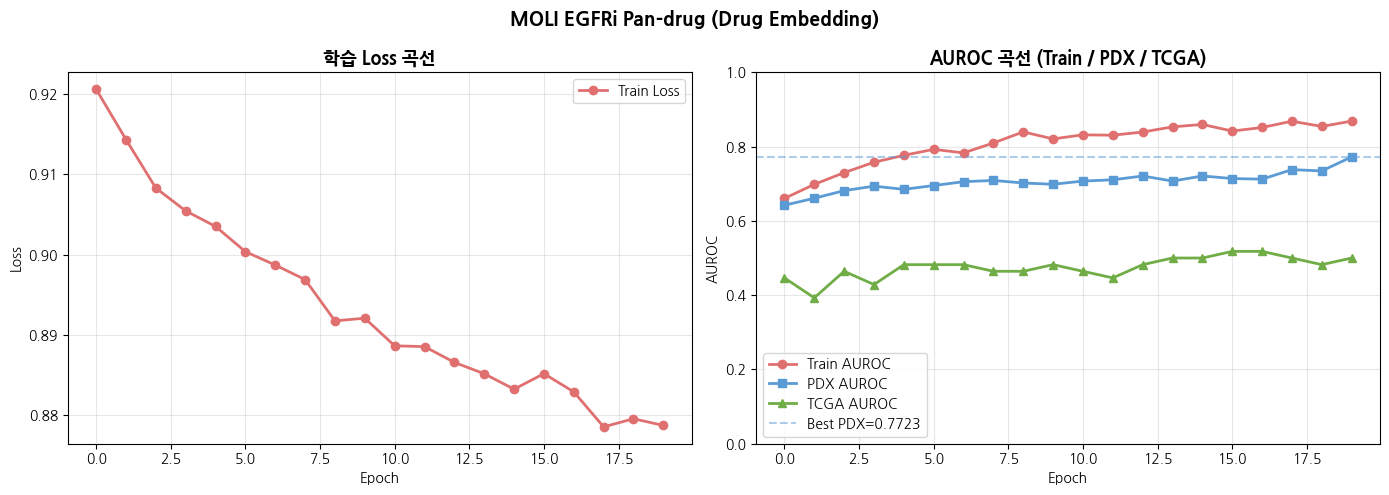

✅ 학습 곡선 저장 완료


In [16]:
# ===================================================
# 8) 학습 곡선 시각화
# ===================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], '-o', color='#E07070', label='Train Loss', linewidth=2)
axes[0].set_title('학습 Loss 곡선', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUROC
axes[1].plot(history['train_auroc'], '-o', color='#E07070', label='Train AUROC', linewidth=2)
axes[1].plot(history['pdx_auroc'],   '-s', color='#5B9BD5', label='PDX AUROC',   linewidth=2)
axes[1].plot(history['tcga_auroc'],  '-^', color='#70AD47', label='TCGA AUROC',  linewidth=2)
axes[1].axhline(y=best_pdx_auroc, color='#5B9BD5', linestyle='--', alpha=0.5,
                label=f'Best PDX={best_pdx_auroc:.4f}')
axes[1].set_title('AUROC 곡선 (Train / PDX / TCGA)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUROC')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('MOLI EGFRi Pan-drug (Drug Embedding)', fontsize=14, fontweight='bold')
plt.tight_layout()

output_dir = "/content/drive/MyDrive/AI Health care 실습파일/MOLI/outputs/EGFRi"
plt.savefig(f'{output_dir}/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 학습 곡선 저장 완료")

In [17]:
# Best 기준: PDX AUROC + AUPR 조합 점수
def combined_score(metrics, w_auroc=0.6, w_aupr=0.4):
    """
    AUROC와 AUPR 가중 조합
    클래스 불균형 시 AUPR이 더 신뢰할 수 있음
    """
    auroc = metrics.get('AUROC', 0.0)
    aupr  = metrics.get('AUPR',  0.0)
    return w_auroc * auroc + w_aupr * aupr

In [18]:
# ===================================================
# 하이퍼파라미터 최적화 (Optuna)
# ===================================================

# 탐색 공간
# 논문 값 기준으로 ±범위 설정
SEARCH_SPACE = {
    'lr_expr'      : (1e-4, 1e-2),   # log scale
    'lr_mut'       : (1e-5, 1e-3),
    'lr_cna'       : (1e-5, 1e-3),
    'lr_cls'       : (1e-4, 1e-2),
    'weight_decay' : (1e-5, 1e-2),
    'dropout_expr' : [0.3, 0.4, 0.5, 0.6],
    'dropout_mut'  : [0.5, 0.6, 0.7, 0.8],
    'dropout_cna'  : [0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    'dropout_cls'  : [0.2, 0.3, 0.4, 0.5],
    'gamma'        : (0.1, 1.0),
    'margin'       : (0.5, 3.0),
    'batch_size'   : [8, 16, 32],
    'hidden_expr'  : [16, 32, 64],
    'hidden_mut'   : [8, 16, 32],
    'hidden_cna'   : [128, 256, 512],
    'drug_emb_dim' : [4, 8, 16],
}

# 모델/옵티마이저 생성 헬퍼
def build_model_and_opts(params):
    m = MOLI(
        INPUT_DIM_EXPR, INPUT_DIM_MUT, INPUT_DIM_CNA,
        hidden_dim_expr = params.get('hidden_expr',  HIDDEN_DIM_EXPR),
        hidden_dim_mut  = params.get('hidden_mut',   HIDDEN_DIM_MUT),
        hidden_dim_cna  = params.get('hidden_cna',   HIDDEN_DIM_CNA),
        drug_emb_dim    = params.get('drug_emb_dim', DRUG_EMB_DIM),
        dropout_expr    = params['dropout_expr'],
        dropout_mut     = params['dropout_mut'],
        dropout_cna     = params['dropout_cna'],
        dropout_cls     = params['dropout_cls'],
    ).to(device)

    opts = (
        optim.Adagrad(m.expr_encoder.parameters(),   lr=params['lr_expr']),
        optim.Adagrad(m.mut_encoder.parameters(),    lr=params['lr_mut']),
        optim.Adagrad(m.cna_encoder.parameters(),    lr=params['lr_cna']),
        optim.Adagrad(m.classifier.parameters(),     lr=params['lr_cls'],
                      weight_decay=params['weight_decay']),
        optim.Adagrad(m.drug_embedding.parameters(), lr=params['lr_cls']),
    )
    return m, opts

In [22]:
def run_single_fold(params, tr_idx, val_idx, max_epochs=30, patience=5):
    """단일 fold 학습 → best score 반환"""

    # DataLoader
    fold_train = OmicsDataset(
        X_train_expr[tr_idx], X_train_mut[tr_idx],
        X_train_cna[tr_idx],  drug_id_train[tr_idx],
        y_train[tr_idx]
    )
    fold_val = OmicsDataset(
        X_train_expr[val_idx], X_train_mut[val_idx],
        X_train_cna[val_idx],  drug_id_train[val_idx],
        y_train[val_idx]
    )

    # Oversampling
    cnt   = np.bincount(y_train[tr_idx].astype(int))
    w     = 1.0 / cnt
    sw    = torch.FloatTensor([w[int(y)] for y in y_train[tr_idx]])
    samp  = WeightedRandomSampler(sw, len(sw), replacement=True)

    bs = params['batch_size']
    tr_loader = DataLoader(fold_train, batch_size=bs,
                           sampler=samp, drop_last=True)
    va_loader = DataLoader(fold_val,   batch_size=bs, shuffle=False)

    # 모델
    m, opts = build_model_and_opts(params)
    trip_crit = nn.TripletMarginLoss(margin=params['margin'], p=2)
    focal_crit  = FocalLoss()
    gamma_val = params['gamma']

    best_score  = 0.0
    patience_cnt = 0

    for epoch in range(max_epochs):
        # 학습
        m.train()
        for expr, mut, cna, drug_id, target in tr_loader:
            if torch.mean(target) in [0., 1.]:
                continue
            expr, mut, cna = expr.to(device), mut.to(device), cna.to(device)
            drug_id, target = drug_id.to(device), target.to(device)

            pred, emb = m.forward_train(expr, mut, cna, drug_id)
            trips = get_hard_triplets(emb, target)
            if trips is None:
                continue

            loss = (gamma_val * trip_crit(emb[trips[:,0]],
                                           emb[trips[:,1]],
                                           emb[trips[:,2]])
                    + focal_crit(pred, target))

            for opt in opts:
                opt.zero_grad()
            loss.backward()
            for opt in opts:
                opt.step()

        # 검증
        m.eval()
        probs, trues = [], []
        with torch.no_grad():
            for expr, mut, cna, drug_id, label in va_loader:
                out = m(expr.to(device), mut.to(device),
                        cna.to(device), drug_id.to(device))
                probs.extend(out.cpu().numpy())
                trues.extend(label.numpy())

        probs = np.array(probs)
        trues = np.array(trues).astype(int)

        if len(np.unique(trues)) < 2:
            continue

        auroc = roc_auc_score(trues, probs)
        aupr  = average_precision_score(trues, probs)
        score = 0.6 * auroc + 0.4 * aupr

        if score > best_score:
            best_score   = score
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break

    del m
    torch.cuda.empty_cache()
    return best_score


def objective(trial):
    """Optuna objective: 3-Fold CV 평균 score 최대화"""

    params = {
        'lr_expr'      : 0.000879,
        'lr_mut'       : 0.000447,
        'lr_cna'       : 3e-5,
        'lr_cls'       : trial.suggest_float('lr_cls',       1e-5, 1e-2,  log=True),
        'weight_decay' : trial.suggest_float('weight_decay', 1e-5, 1e-2,  log=True),
        'dropout_expr' : trial.suggest_categorical('dropout_expr', [0.3, 0.4, 0.5, 0.6]),
        'dropout_mut'  : trial.suggest_categorical('dropout_mut',  [0.4, 0.5, 0.6, 0.7]),
        'dropout_cna'  : trial.suggest_categorical('dropout_cna',  [0.4, 0.5, 0.6, 0.7]),
        'dropout_cls'  : trial.suggest_categorical('dropout_cls',  [0.3, 0.4, 0.5, 0.6]),
        'gamma'        : trial.suggest_float('gamma',   0.3, 1.0),
        'margin'       : trial.suggest_float('margin',  1.2, 2.0),
        'batch_size'   : 16,
        'hidden_expr'  : trial.suggest_categorical('hidden_expr',  [16, 32, 64]),
        'hidden_mut'   : trial.suggest_categorical('hidden_mut',   [8, 16, 32]),
        'hidden_cna'   : trial.suggest_categorical('hidden_cna',   [64, 96, 128, 160]),
        'drug_emb_dim' : trial.suggest_categorical('drug_emb_dim', [4, 8, 16]),
    }

    # 3-Fold CV
    skf    = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for fold, (tr_idx, va_idx) in enumerate(
            skf.split(np.arange(len(y_train)), y_train.astype(int))):

        score = run_single_fold(
            params, tr_idx, va_idx,
            max_epochs = 25,
            patience   = 5
        )
        scores.append(score)

        # Pruning: 첫 2 fold 결과가 너무 낮으면 조기 종료
        trial.report(np.mean(scores), fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(scores)

In [23]:
# ===================================================
# Optuna 실행
# ===================================================
N_TRIALS = 100

study = optuna.create_study(
    direction  = 'maximize',
    study_name = 'MOLI_EGFRi_Pandrug',
    sampler    = optuna.samplers.TPESampler(seed=42),
    pruner     = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)

# 찾은 파라미터를 시작점으로 추가 (Trial 0)
study.enqueue_trial({
    'lr_expr'      : 0.000879,
    'lr_mut'       : 0.000447,
    'lr_cna'       : 3e-5,
    'lr_cls'       : 0.01,
    'weight_decay' : 0.000177932,
    'dropout_expr' : 0.4,
    'dropout_mut'  : 0.7,
    'dropout_cna'  : 0.7,
    'dropout_cls'  : 0.5,
    'gamma'        : 0.44,
    'margin'       : 1.68,
    'batch_size'   : 16,
    'hidden_expr'  : 32,
    'hidden_mut'   : 8,
    'hidden_cna'   : 128,
    'drug_emb_dim' : 16,
})

print(f"🔍 Optuna 최적화 시작")
print(f"   Trials: {N_TRIALS} | Sampler: TPE | Pruner: Median")
print(f"   각 Trial = 3-Fold CV (max 25 epochs, patience 5)")
print("=" * 60)

with tqdm(total=N_TRIALS, desc="Optuna") as pbar:
    def callback(study, trial):
        pbar.update(1)
        pbar.set_postfix(
            best  = f"{study.best_value:.4f}",
            trial = trial.number,
            state = trial.state.name[:4]
        )
    study.optimize(objective, n_trials=N_TRIALS,
                   callbacks=[callback], gc_after_trial=True)

# 결과 출력
print("\n" + "=" * 60)
print(f"🏆 최적화 완료")
print(f"  Best score : {study.best_value:.4f}")
print(f"  Best trial : #{study.best_trial.number}")
print(f"\n  Best params:")
for k, v in study.best_params.items():
    paper = {'lr_expr':0.001,'lr_mut':0.0001,'lr_cna':5e-5,
             'lr_cls':0.005,'weight_decay':0.0001,'dropout_expr':0.5,
             'dropout_mut':0.8,'dropout_cna':0.5,'dropout_cls':0.3,
             'gamma':0.5,'margin':1.5,'batch_size':16}
    arrow = "←논문" if k in paper and abs(float(v)-float(paper[k]))<1e-9 else ""
    print(f"    {k:15s}: {v}  {arrow}")

# 파라미터 중요도
print("\n📊 파라미터 중요도:")
try:
    imp = optuna.importance.get_param_importances(study)
    for k, v in imp.items():
        bar = '█' * int(v * 25)
        print(f"  {k:15s}: {bar:<25s} {v:.3f}")
except Exception as e:
    print(f"  (중요도 계산 불가: {e})")

# study 저장
with open(f"{save_dir}/optuna_study.pkl", 'wb') as f:
    pickle.dump(study, f)
print("\n✅ study 저장 완료 (optuna_study.pkl)")

🔍 Optuna 최적화 시작
   Trials: 100 | Sampler: TPE | Pruner: Median
   각 Trial = 3-Fold CV (max 25 epochs, patience 5)


Optuna: 100%|██████████| 100/100 [2:34:23<00:00, 92.63s/it, best=0.7193, state=COMP, trial=99]



🏆 최적화 완료
  Best score : 0.7193
  Best trial : #96

  Best params:
    lr_cls         : 0.009699482880133196  
    weight_decay   : 0.0071253694108754624  
    dropout_expr   : 0.6  
    dropout_mut    : 0.5  
    dropout_cna    : 0.4  
    dropout_cls    : 0.3  ←논문
    gamma          : 0.5579620592362088  
    margin         : 1.9773400393437335  
    hidden_expr    : 64  
    hidden_mut     : 16  
    hidden_cna     : 160  
    drug_emb_dim   : 16  

📊 파라미터 중요도:
  lr_cls         : ████████████████████      0.832
  hidden_expr    : ██                        0.093
  margin         :                           0.036
  weight_decay   :                           0.010
  gamma          :                           0.007
  hidden_cna     :                           0.005
  dropout_expr   :                           0.004
  dropout_mut    :                           0.004
  dropout_cna    :                           0.003
  dropout_cls    :                           0.003
  drug_emb_dim   :   

In [25]:
# ===================================================
# 최적 파라미터로 최종 학습
# ===================================================
best_params = params = {
        'lr_expr'      : 0.000879,
        'lr_mut'       : 0.000447,
        'lr_cna'       : 3e-5,
        'lr_cls'       : 0.009699482880133196,
        'weight_decay' : 0.0071253694108754624,
        'dropout_expr' : 0.6,
        'dropout_mut'  : 0.5,
        'dropout_cna'  : 0.4,
        'dropout_cls'  : 0.3,
        'gamma'        : 0.5579620592362088,
        'margin'       : 1.9773400393437335,
        'batch_size'   : 16,
        'hidden_expr'  : 64,
        'hidden_mut'   : 16,
        'hidden_cna'   : 160,
        'drug_emb_dim' : 16,
    }
print(f"🚀 최적 파라미터로 최종 학습")

# 전체 Train 데이터로 학습
final_model, final_opts = build_model_and_opts(best_params)
trip_crit_final = nn.TripletMarginLoss(margin=best_params['margin'], p=2)

bs_final = best_params['batch_size']
final_sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
final_loader  = DataLoader(
    train_dataset, batch_size=bs_final,
    sampler=final_sampler, drop_last=True
    )

best_score_final = 0.0
best_state_final = None
patience_cnt     = 0
PATIENCE_FINAL   = 10
MAX_EPOCHS_FINAL = 80

history_final = {'train_loss':[],'train_auroc':[], 'pdx_cetu':[],'pdx_erlo':[],'tcga':[]}

print("=" * 65)
for epoch in range(MAX_EPOCHS_FINAL):

    # 학습
    final_model.train()
    ep_loss, ep_auc, n_b = 0.0, [], 0
    for expr, mut, cna, drug_id, target in final_loader:
        if torch.mean(target) in [0., 1.]:
            continue
        expr, mut, cna = expr.to(device), mut.to(device), cna.to(device)
        drug_id, target = drug_id.to(device), target.to(device)
        pred, emb = final_model.forward_train(expr, mut, cna, drug_id)
        trips = get_hard_triplets(emb, target)
        if trips is None:
            continue
        loss = (best_params['gamma'] *
                trip_crit_final(emb[trips[:,0]], emb[trips[:,1]], emb[trips[:,2]])
                + focal_loss(pred, target))
        for opt in final_opts:
            opt.zero_grad()
        loss.backward()
        for opt in final_opts:
            opt.step()
        ep_loss += loss.item()
        n_b     += 1
        y_t = target.cpu().numpy().astype(int)
        y_p = pred.detach().cpu().numpy()
        if len(np.unique(y_t)) == 2:
            ep_auc.append(roc_auc_score(y_t, y_p))

    avg_loss  = ep_loss / max(n_b, 1)
    avg_auroc = np.mean(ep_auc) if ep_auc else 0.0

    # 검증
    pdx_res  = evaluate(final_model, val_loader,  device)
    tcga_res = evaluate(final_model, tcga_loader, device)

    pdx_cetu = pdx_res.get('Cetuximab', {}).get('AUROC', 0.0)
    pdx_erlo = pdx_res.get('Erlotinib', {}).get('AUROC', 0.0)
    pdx_auc = pdx_res.get('overall', {}).get('AUROC',  0.0)
    pdx_aupr = pdx_res.get('overall', {}).get('AUPR',  0.0)
    tcga_auc = tcga_res.get('overall', {}).get('AUROC',  0.0)

    # Best 기준: PDX AUROC×0.6 + AUPR×0.4
    score = 0.6 * pdx_auc + 0.4 * pdx_aupr
    is_best    = score > best_score_final
    if is_best:
        best_score_final = score
        best_state_final = deepcopy(final_model.state_dict())
        patience_cnt = 0
    else:
        patience_cnt += 1

    history_final['train_loss'].append(avg_loss)
    history_final['train_auroc'].append(avg_auroc)
    history_final['pdx_cetu'].append(pdx_cetu)
    history_final['pdx_erlo'].append(pdx_erlo)
    history_final['tcga'].append(tcga_auc)

    print(f"Epoch {epoch+1:>2} | loss={avg_loss:.4f} | "
          f"train={avg_auroc:.4f} | "
          f"PDX_Cetu={pdx_cetu:.4f} | "
          f"PDX_Erlo={pdx_erlo:.4f} | "
          f"TCGA={tcga_auc:.4f}"
          + (" ⭐" if is_best else f" [{patience_cnt}/{PATIENCE_FINAL}]"))

    if patience_cnt >= PATIENCE_FINAL:
        print(f"\n⏹ Early Stopping at epoch {epoch+1}")
        break

print("=" * 65)
final_model.load_state_dict(best_state_final)
print(f"\n🏆 Best score: {best_score_final:.4f}")
_ = evaluate(final_model, val_loader,  device, dataset_name="PDX  (최종)")
_ = evaluate(final_model, tcga_loader, device, dataset_name="TCGA (최종)")

🚀 최적 파라미터로 최종 학습
Epoch  1 | loss=1.2856 | train=0.6714 | PDX_Cetu=0.6364 | PDX_Erlo=0.6481 | TCGA=0.4821 ⭐
Epoch  2 | loss=1.2754 | train=0.7389 | PDX_Cetu=0.6327 | PDX_Erlo=0.6481 | TCGA=0.5000 ⭐
Epoch  3 | loss=1.2717 | train=0.7619 | PDX_Cetu=0.6073 | PDX_Erlo=0.6481 | TCGA=0.5000 ⭐
Epoch  4 | loss=1.2663 | train=0.7814 | PDX_Cetu=0.6109 | PDX_Erlo=0.6852 | TCGA=0.5179 ⭐
Epoch  5 | loss=1.2640 | train=0.7879 | PDX_Cetu=0.6182 | PDX_Erlo=0.7222 | TCGA=0.5357 ⭐
Epoch  6 | loss=1.2587 | train=0.8206 | PDX_Cetu=0.6073 | PDX_Erlo=0.7222 | TCGA=0.5357 [1/10]
Epoch  7 | loss=1.2571 | train=0.8206 | PDX_Cetu=0.5927 | PDX_Erlo=0.7407 | TCGA=0.5714 [2/10]
Epoch  8 | loss=1.2577 | train=0.8161 | PDX_Cetu=0.6000 | PDX_Erlo=0.7222 | TCGA=0.5714 [3/10]
Epoch  9 | loss=1.2562 | train=0.8286 | PDX_Cetu=0.5964 | PDX_Erlo=0.7407 | TCGA=0.5536 ⭐
Epoch 10 | loss=1.2515 | train=0.8442 | PDX_Cetu=0.6036 | PDX_Erlo=0.7222 | TCGA=0.5893 [1/10]
Epoch 11 | loss=1.2469 | train=0.8491 | PDX_Cetu=0.5891 | PDX_E

In [26]:
# ===================================================
# 학습 함수 정의_학습 기준 변경
# ===================================================

def train_one_epoch(model, loader, optimizers, device):
    """한 epoch 학습 → (avg_loss, avg_auroc) 반환"""
    model.train()
    epoch_loss  = 0.0
    epoch_auroc = []
    n_batches   = 0

    solverE, solverM, solverC, solverCLS, solverDRUG = optimizers

    for expr, mut, cna, drug_id, target in loader:

        if torch.mean(target) == 0. or torch.mean(target) == 1.:
            continue

        expr    = expr.to(device)
        mut     = mut.to(device)
        cna     = cna.to(device)
        drug_id = drug_id.to(device)
        target  = target.to(device)

        pred, embeddings = model.forward_train(expr, mut, cna, drug_id)

        triplets = get_hard_triplets(embeddings, target)
        if triplets is None:
            continue

        trip_loss = trip_criterion(
            embeddings[triplets[:, 0]],
            embeddings[triplets[:, 1]],
            embeddings[triplets[:, 2]]
        )
        bce  = bce_loss(pred, target)
        loss = GAMMA * trip_loss + bce

        for opt in optimizers:
            opt.zero_grad()
        loss.backward()
        for opt in optimizers:
            opt.step()

        epoch_loss += loss.item()
        n_batches  += 1

        y_t = target.cpu().numpy().astype(int)
        y_p = pred.detach().cpu().numpy()
        if len(np.unique(y_t)) == 2:
            epoch_auroc.append(roc_auc_score(y_t, y_p))

    avg_loss  = epoch_loss / max(n_batches, 1)
    avg_auroc = np.mean(epoch_auroc) if epoch_auroc else 0.0
    return avg_loss, avg_auroc

print("✅ 학습 함수 준비 완료")

✅ 학습 함수 준비 완료


In [28]:
# ===================================================
# 5-Fold CV + Early Stopping
# ===================================================

best_params = {
        'lr_expr'      : 0.000879,
        'lr_mut'       : 0.000447,
        'lr_cna'       : 3e-5,
        'lr_cls'       : 0.009699482880133196,
        'weight_decay' : 0.0071253694108754624,
        'dropout_expr' : 0.6,
        'dropout_mut'  : 0.5,
        'dropout_cna'  : 0.4,
        'dropout_cls'  : 0.3,
        'gamma'        : 0.5579620592362088,
        'margin'       : 1.9773400393437335,
        'batch_size'   : 16,
        'hidden_expr'  : 64,
        'hidden_mut'   : 16,
        'hidden_cna'   : 160,
        'drug_emb_dim' : 16,
    }

def run_cv(params, n_splits=5, max_epochs=50, patience=7, verbose=True):

    # Trip/BCE loss는 파라미터에 따라 새로 생성
    trip_crit = nn.TripletMarginLoss(margin=best_params['margin'], p=2)
    bce_crit  = nn.BCELoss()

    # 전체 Train 데이터 인덱스
    indices = np.arange(len(y_train))
    skf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    best_state_fold = []
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(indices, y_train.astype(int))):

        if verbose:
            print(f"\n  📂 Fold {fold+1}/{n_splits}")

        # Fold별 데이터셋
        fold_train = OmicsDataset(
            X_train_expr[tr_idx],  X_train_mut[tr_idx],
            X_train_cna[tr_idx],   drug_id_train[tr_idx],
            y_train[tr_idx]
        )
        fold_val = OmicsDataset(
            X_train_expr[val_idx], X_train_mut[val_idx],
            X_train_cna[val_idx],  drug_id_train[val_idx],
            y_train[val_idx]
        )

        # Oversampling (Fold Train만 적용)
        fold_class_counts  = np.bincount(y_train[tr_idx].astype(int))
        fold_class_weights = 1.0 / fold_class_counts
        fold_sample_w = torch.FloatTensor(
            [fold_class_weights[int(y)] for y in y_train[tr_idx]]
        )
        fold_sampler = WeightedRandomSampler(
            fold_sample_w, len(fold_sample_w), replacement=True
        )

        fold_train_loader = DataLoader(
            fold_train, batch_size=BATCH_SIZE,
            sampler=fold_sampler, drop_last=True
        )
        fold_val_loader = DataLoader(
            fold_val, batch_size=BATCH_SIZE, shuffle=False
        )

        # 모델 + Optimizer
        model_cv, optimizers_cv = build_model_and_opts(best_params)

        # Early Stopping 변수
        best_score    = 0.0
        best_state    = None
        patience_cnt  = 0

        for epoch in range(max_epochs):

            # 1) 학습
            avg_loss, avg_auroc = train_one_epoch(
                model_cv, fold_train_loader, optimizers_cv, device
            )

            # 2) 검증 (Fold Val = Train 일부)
            fold_val_results = evaluate(model_cv, fold_val_loader, device)
            fold_metrics     = fold_val_results.get('overall', {})
            auc              = fold_val_results.get('overall', {}).get('AUROC', 0.0)
            aupr             = fold_val_results.get('overall', {}).get('AUPR',  0.0)
            score            = 0.6 * auc + 0.4 * aupr

            # 3) Best 기준: AUROC + AUPR 조합 점수
            if score > best_score:
                best_score = score
                best_state = deepcopy(model_cv.state_dict())
                patience_cnt = 0
            else:
                patience_cnt += 1

            if verbose:
                auroc = fold_metrics.get('AUROC', 0.0)
                aupr  = fold_metrics.get('AUPR',  0.0)
                mark  = " ⭐" if patience_cnt == 0 else ""
                print(f"    Epoch {epoch+1:>2} | loss={avg_loss:.4f} | "
                      f"AUROC={auroc:.4f} AUPR={aupr:.4f} "
                      f"score={score:.4f}{mark} "
                      f"[patience {patience_cnt}/{patience}]")

            # 4) Early Stopping
            if patience_cnt >= patience:
                if verbose:
                    print(f"    ⏹ Early Stopping at epoch {epoch+1}")
                break

        best_state_fold.append(best_state)
        fold_scores.append(best_score)
        if verbose:
            print(f"  ✅ Fold {fold+1} Best score: {best_score:.4f}")

    return best_state_fold, fold_scores


# 5-fold CV 시작

print("🔁 5-Fold CV 시작")
print(f"   Early Stopping patience=7 | max_epochs=50")
print(f"   Best 기준: AUROC×0.6 + AUPR×0.4")
print("=" * 60)

best_state, cv_scores = run_cv(best_params, n_splits=5, max_epochs=50, patience=7)

print("\n" + "=" * 60)
print(f"📊 5-Fold CV 결과:")
for i, s in enumerate(cv_scores):
    print(f"  Fold {i+1}: {s:.4f}")
print(f"  평균: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

🔁 5-Fold CV 시작
   Early Stopping patience=7 | max_epochs=50
   Best 기준: AUROC×0.6 + AUPR×0.4

  📂 Fold 1/5
    Epoch  1 | loss=1.4722 | AUROC=0.8119 AUPR=0.5188 score=0.6947 ⭐ [patience 0/7]
    Epoch  2 | loss=1.4288 | AUROC=0.8176 AUPR=0.5433 score=0.7079 ⭐ [patience 0/7]
    Epoch  3 | loss=1.4036 | AUROC=0.8195 AUPR=0.5476 score=0.7107 ⭐ [patience 0/7]
    Epoch  4 | loss=1.3911 | AUROC=0.8225 AUPR=0.5688 score=0.7210 ⭐ [patience 0/7]
    Epoch  5 | loss=1.3681 | AUROC=0.8192 AUPR=0.5674 score=0.7185 [patience 1/7]
    Epoch  6 | loss=1.3424 | AUROC=0.8245 AUPR=0.5709 score=0.7231 ⭐ [patience 0/7]
    Epoch  7 | loss=1.3281 | AUROC=0.8166 AUPR=0.5639 score=0.7155 [patience 1/7]
    Epoch  8 | loss=1.3199 | AUROC=0.8191 AUPR=0.5670 score=0.7183 [patience 2/7]
    Epoch  9 | loss=1.3131 | AUROC=0.8169 AUPR=0.5658 score=0.7165 [patience 3/7]
    Epoch 10 | loss=1.2920 | AUROC=0.8167 AUPR=0.5617 score=0.7147 [patience 4/7]
    Epoch 11 | loss=1.2794 | AUROC=0.8174 AUPR=0.5651 score=0.7

In [29]:
print("=" * 60)
aurocs = []

for i, state in enumerate(best_state):
    model_cv, _ = build_model_and_opts(best_params)
    model_cv.load_state_dict(state)
    model_cv.to(device)

    print("\n✅ Best 모델 로드 완료 → 최종 평가")
    res = evaluate(model_cv, val_loader, device, dataset_name="PDX (Best)")

    auroc = res.get("overall", {}).get("AUROC", 0.0)
    aurocs.append(auroc)
    print(f"Fold {i+1} PDX AUROC: {auroc:.4f}")

print(f"\n[최종 결과] 평균 PDX AUROC: {np.mean(aurocs):.4f}")


✅ Best 모델 로드 완료 → 최종 평가

📊 PDX (Best) 평가 결과
  [전체]
    AUROC     : 0.6130
    AUPR      : 0.2684
    Recall    : 0.5000
    Precision : 0.1905
    F1        : 0.2759
    F2        : 0.3774
  [💊 Cetuximab]
    AUROC     : 0.5636
    AUPR      : 0.2077
    Recall    : 0.4000
    Precision : 0.1667
    F1        : 0.2353
    F2        : 0.3125
  [💊 Erlotinib]
    AUROC     : 0.6852
    AUPR      : 0.4444
    Recall    : 0.6667
    Precision : 0.2222
    F1        : 0.3333
    F2        : 0.4762
Fold 1 PDX AUROC: 0.6130

✅ Best 모델 로드 완료 → 최종 평가

📊 PDX (Best) 평가 결과
  [전체]
    AUROC     : 0.6832
    AUPR      : 0.2339
    Recall    : 0.5000
    Precision : 0.2667
    F1        : 0.3478
    F2        : 0.4255
  [💊 Cetuximab]
    AUROC     : 0.6909
    AUPR      : 0.2058
    Recall    : 0.4000
    Precision : 0.2222
    F1        : 0.2857
    F2        : 0.3448
  [💊 Erlotinib]
    AUROC     : 0.6852
    AUPR      : 0.3922
    Recall    : 0.6667
    Precision : 0.3333
    F1        : 0.4444
  

In [30]:
print("=" * 60)
aurocs = []

for i, state in enumerate(best_state):
    model_cv, _ = build_model_and_opts(best_params)
    model_cv.load_state_dict(state)
    model_cv.to(device)

    print("\n✅ Best 모델 로드 완료 → 최종 평가")
    res = evaluate(model_cv, tcga_loader, device, dataset_name="TCGA (Best)")

    auroc = res.get("overall", {}).get("AUROC", 0.0)
    aurocs.append(auroc)
    print(f"Fold {i+1} TCGA AUROC: {auroc:.4f}")

print(f"\n[최종 결과] 평균 TCGA AUROC: {np.mean(aurocs):.4f}")


✅ Best 모델 로드 완료 → 최종 평가

📊 TCGA (Best) 평가 결과
  [전체]
    AUROC     : 0.5000
    AUPR      : 0.4882
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Cetuximab]
    AUROC     : 0.2917
    AUPR      : 0.5327
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
  [💊 Erlotinib]
    AUROC     : 0.5000
    AUPR      : 0.5000
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000
    F2        : 0.0000
Fold 1 TCGA AUROC: 0.5000

✅ Best 모델 로드 완료 → 최종 평가

📊 TCGA (Best) 평가 결과
  [전체]
    AUROC     : 0.5536
    AUPR      : 0.5158
    Recall    : 0.1429
    Precision : 0.3333
    F1        : 0.2000
    F2        : 0.1613
  [💊 Cetuximab]
    AUROC     : 0.4583
    AUPR      : 0.5931
    Recall    : 0.1667
    Precision : 0.3333
    F1        : 0.2222
    F2        : 0.1852
  [💊 Erlotinib]
    AUROC     : 0.0000
    AUPR      : 0.3333
    Recall    : 0.0000
    Precision : 0.0000
    F1        : 0.0000

In [31]:
# 오분류 분석
def error_analysis(model, loader, device, dataset_name=""):
    model.eval()
    all_probs, all_labels, all_drug_ids = [], [], []
    all_expr, all_mut, all_cna = [], [], []

    with torch.no_grad():
        for expr, mut, cna, drug_id, label in loader:
            out = model(expr.to(device), mut.to(device),
                        cna.to(device), drug_id.to(device))
            all_probs.extend(out.cpu().numpy())
            all_labels.extend(label.numpy())
            all_drug_ids.extend(drug_id.numpy())
            all_expr.extend(expr.numpy())
            all_mut.extend(mut.numpy())
            all_cna.extend(cna.numpy())

    y_prob   = np.array(all_probs)
    y_true   = np.array(all_labels).astype(int)
    drug_ids = np.array(all_drug_ids)
    y_pred   = (y_prob >= 0.5).astype(int)

    # 오분류 유형 분류
    # FN: 실제 S인데 R로 예측 → 치료 기회 손실
    # FP: 실제 R인데 S로 예측 → 불필요한 치료
    fn_mask = (y_true == 1) & (y_pred == 0)  # False Negative
    fp_mask = (y_true == 0) & (y_pred == 1)  # False Positive
    tp_mask = (y_true == 1) & (y_pred == 1)  # True Positive
    tn_mask = (y_true == 0) & (y_pred == 0)  # True Negative

    print(f"\n{'='*50}")
    print(f"📊 {dataset_name} 오분류 분석")
    print(f"{'='*50}")
    print(f"TP: {tp_mask.sum():3d}  FP: {fp_mask.sum():3d}")
    print(f"FN: {fn_mask.sum():3d}  TN: {tn_mask.sum():3d}")

    print(f"\n--- FN (실제 S → R 예측, 치료 기회 손실) ---")
    for i in np.where(fn_mask)[0]:
        drug = IDX_TO_DRUG[drug_ids[i]]
        print(f"  idx={i:3d} | {drug:12s} | prob={y_prob[i]:.4f} | "
              f"확신도: {'낮음' if y_prob[i] > 0.4 else '높음(잘못된 방향)'}")

    print(f"\n--- FP (실제 R → S 예측, 불필요한 치료) ---")
    for i in np.where(fp_mask)[0]:
        drug = IDX_TO_DRUG[drug_ids[i]]
        print(f"  idx={i:3d} | {drug:12s} | prob={y_prob[i]:.4f} | "
              f"확신도: {'낮음' if y_prob[i] < 0.6 else '높음(잘못된 방향)'}")

    # 약물별 오류 패턴
    print(f"\n--- 약물별 오류 분포 ---")
    for drug_name, drug_idx in DRUG_TO_IDX.items():
        mask = (drug_ids == drug_idx)
        if mask.sum() == 0:
            continue
        n_fn = int(fn_mask[mask].sum())
        n_fp = int(fp_mask[mask].sum())
        n_tp = int(tp_mask[mask].sum())
        n_tn = int(tn_mask[mask].sum())
        if n_fn + n_fp + n_tp + n_tn == 0:
            continue
        print(f"  {drug_name:12s}: TP={n_tp} FP={n_fp} FN={n_fn} TN={n_tn}")

    # 확률 분포 분석
    print(f"\n--- 확률 분포 (경계 근처 샘플) ---")
    boundary = (y_prob >= 0.4) & (y_prob <= 0.6)
    print(f"  0.4~0.6 구간 샘플: {boundary.sum()}개 "
          f"(전체의 {boundary.sum()/len(y_prob)*100:.1f}%)")
    print(f"  → 이 샘플들이 threshold 변경에 가장 민감하게 반응")

    # S 샘플 확률 분포
    s_probs = y_prob[y_true == 1]
    r_probs = y_prob[y_true == 0]
    print(f"\n--- 클래스별 예측 확률 분포 ---")
    print(f"  S 샘플: min={s_probs.min():.3f} "
          f"mean={s_probs.mean():.3f} max={s_probs.max():.3f}")
    print(f"  R 샘플: min={r_probs.min():.3f} "
          f"mean={r_probs.mean():.3f} max={r_probs.max():.3f}")

    # threshold sweep: 어디서 FN이 0이 되는지
    print(f"\n--- Threshold Sweep (FN=0 지점 탐색) ---")
    print(f"  thresh | TP  FP  FN  TN | Recall | Precision | F2")
    print(f"  {'─'*55}")
    for t in np.arange(0.3, 0.7, 0.05):
        yp = (y_prob >= t).astype(int)
        tp = int(((y_true==1)&(yp==1)).sum())
        fp = int(((y_true==0)&(yp==1)).sum())
        fn = int(((y_true==1)&(yp==0)).sum())
        tn = int(((y_true==0)&(yp==0)).sum())
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0
        prec = tp/(tp+fp) if (tp+fp)>0 else 0
        f2   = (5*prec*rec)/(4*prec+rec) if (prec+rec)>0 else 0
        marker = " ← FN=0" if fn == 0 else ""
        print(f"  {t:.2f}   | {tp:2d}  {fp:2d}  {fn:2d}  {tn:2d}  "
              f"| {rec:.3f}  | {prec:.3f}     | {f2:.3f}{marker}")

    return {
        'y_prob': y_prob, 'y_true': y_true,
        'drug_ids': drug_ids,
        'fn_idx': np.where(fn_mask)[0],
        'fp_idx': np.where(fp_mask)[0],
    }

# 실행
final_model.load_state_dict(best_state_final)
print("=== PDX 오분류 분석 ===")
pdx_errors  = error_analysis(final_model, val_loader,  device, "PDX")
print("\n=== TCGA 오분류 분석 ===")
tcga_errors = error_analysis(final_model, tcga_loader, device, "TCGA")

=== PDX 오분류 분석 ===

📊 PDX 오분류 분석
TP:   5  FP:  16
FN:   3  TN:  57

--- FN (실제 S → R 예측, 치료 기회 손실) ---
  idx= 16 | Cetuximab    | prob=0.4335 | 확신도: 낮음
  idx= 20 | Cetuximab    | prob=0.4660 | 확신도: 낮음
  idx= 68 | Cetuximab    | prob=0.4198 | 확신도: 낮음

--- FP (실제 R → S 예측, 불필요한 치료) ---
  idx= 23 | Cetuximab    | prob=0.5012 | 확신도: 낮음
  idx= 24 | Erlotinib    | prob=0.5069 | 확신도: 낮음
  idx= 25 | Cetuximab    | prob=0.5412 | 확신도: 낮음
  idx= 33 | Cetuximab    | prob=0.6535 | 확신도: 높음(잘못된 방향)
  idx= 34 | Cetuximab    | prob=0.5232 | 확신도: 낮음
  idx= 41 | Erlotinib    | prob=0.5034 | 확신도: 낮음
  idx= 42 | Cetuximab    | prob=0.5540 | 확신도: 낮음
  idx= 43 | Erlotinib    | prob=0.5603 | 확신도: 낮음
  idx= 45 | Cetuximab    | prob=0.5451 | 확신도: 낮음
  idx= 46 | Erlotinib    | prob=0.5499 | 확신도: 낮음
  idx= 65 | Cetuximab    | prob=0.6001 | 확신도: 높음(잘못된 방향)
  idx= 66 | Cetuximab    | prob=0.5874 | 확신도: 낮음
  idx= 67 | Erlotinib    | prob=0.5918 | 확신도: 낮음
  idx= 69 | Cetuximab    | prob=0.5100 | 확신도: 낮음
  idx= 70 | C

In [32]:
import json

# best_state_final에 저장된 최적 가중치 로드
final_model.load_state_dict(best_state_final)
final_model.eval()

# 1. 모델 가중치 저장
output_dir = "/content/drive/MyDrive/AI Health care 실습파일/MOLI/outputs/EGFRi"
torch.save(final_model.state_dict(), f'{output_dir}/model_G.pth')
print(f"✅ model_G.pth 저장 완료")

# 2. 모델 구조 및 설정 저장
model_config = {
    'INPUT_DIM_EXPR' : int(INPUT_DIM_EXPR),
    'INPUT_DIM_MUT'  : int(INPUT_DIM_MUT),
    'INPUT_DIM_CNA'  : int(INPUT_DIM_CNA),
    'HIDDEN_DIM_EXPR': best_params['hidden_expr'],
    'HIDDEN_DIM_MUT' : best_params['hidden_mut'],
    'HIDDEN_DIM_CNA' : best_params['hidden_cna'],
    'DRUG_EMB_DIM'   : best_params['drug_emb_dim'],
    'NUM_DRUGS'      : NUM_DRUGS,
    'Z_TOTAL'        : 184,
    'DROPOUT_EXPR'   : best_params['dropout_expr'],
    'DROPOUT_MUT'    : best_params['dropout_mut'],
    'DROPOUT_CNA'    : best_params['dropout_cna'],
    'DROPOUT_CLS'    : best_params['dropout_cls'],
    'DRUG_TO_IDX'    : DRUG_TO_IDX,
    'best_params'    : best_params,   # Optuna 최적 하이퍼파라미터도 같이 저장
    'threshold'      : 0.40,
}


with open(f'{output_dir}/model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)
print(f"✅ model_config.json 저장 완료")

# 3. 저장 확인
import os
print(f"\n저장된 파일:")
for fname in ['model_G.pth', 'model_config.json']:
    fpath = f'{output_dir}/{fname}'
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / 1024 / 1024
        print(f"  {fname}: {size:.1f} MB")
    else:
        print(f"  {fname}: ❌ 없음")

✅ model_G.pth 저장 완료
✅ model_config.json 저장 완료

저장된 파일:
  model_G.pth: 17.9 MB
  model_config.json: 0.0 MB
